# 허위매물 온도 분석  

---

In [1]:
import pandas as pd
import json
import glob
import os

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# 한글 폰트 설정
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

print("="*60)
print("지역별 허위매물 온도 분석 시작")
print("="*60)

지역별 허위매물 온도 분석 시작


# 부동산 중개업소

In [3]:
# 1. 서울시 부동산 중개업소 정보 JSON 읽기
with open('../data/regionTemp/saleLand/서울시 부동산 중개업소 정보.json', 'r', encoding='utf-8') as f:
    broker_data = json.load(f)

broker_df = pd.DataFrame(broker_data['DATA'])
print("=== 서울시 부동산 중개업소 정보 ===")
print(f"데이터 shape: {broker_df.shape}")
print(broker_df.head())

=== 서울시 부동산 중개업소 정보 ===
데이터 shape: (25450, 21)
  pbadms_dsps_end_dd pbadms_dsps_strt_dd stts_se sgg_cd mdt_bsns_nm  \
0               None                None     영업중  11440         김은정   
1               None                None     영업중  11680         오해숙   
2               None                None     영업중  11680         양신숙   
3               None                None     영업중  11680         정경표   
4               None                None     영업중  11680         박규리   

        sys_reg_no   sno                                              telno  \
0  114402022000106  0000                                        02-718-3636   
1  116802022000266  0000                                      , 02-562-6985   
2  116802022000269  0000                                        02-572-8880   
3  116802022000259  0019                                        02-552-0113   
4  116802022000253  0000  02-512-2232, 02-547-2227, 02-518-2232, 02-515-...   

  lotno_se                                         

> 서울시 구별 중개업소 분포 분석

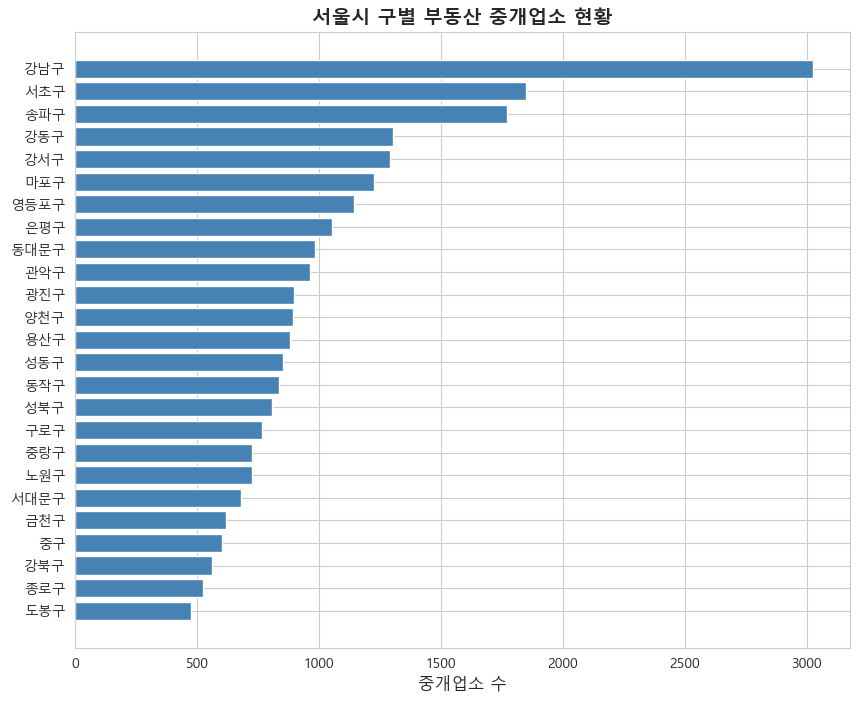

In [22]:
# 구 이름 추출
# 주소 컬럼에서 정규표현식을 사용하여 '서울특별시' 다음에 오는 '구' 단위 지역명을 추출
broker_df['region'] = broker_df['addr'].str.extract(r'서울특별시\s*(\S+구)')

# 구별 집계
# 각 구별로 중개업소 개수를 집계하고, 'broker_count' 컬럼명으로 결과를 저장
broker_by_region = broker_df.groupby('region').size().reset_index(name='broker_count')

# 시각화 설정
plt.figure(figsize=(10, 8))  # 그래프 크기 설정 (가로 10, 세로 8)
plt.rcParams['font.family'] = 'Malgun Gothic'  # 한글 폰트 설정 (맑은 고딕)

# 데이터 정렬
# 중개업소 수를 기준으로 내림차순 정렬 (많은 순서대로)
broker_sorted = broker_by_region.sort_values('broker_count', ascending=False)

# 가로 막대 그래프 생성
# 구 이름을 y축에, 중개업소 수를 x축에 표시
plt.barh(broker_sorted['region'], broker_sorted['broker_count'], color='steelblue')

# 그래프 레이블 및 제목 설정
plt.xlabel('중개업소 수', fontsize=12)  # x축 레이블
plt.title('서울시 구별 부동산 중개업소 현황', fontsize=14, fontweight='bold')  # 그래프 제목

# y축 순서 반전 (가장 많은 구가 위에 오도록)
plt.gca().invert_yaxis()

# 그래프 출력
plt.show()


> 서울시 구별 부동산 중개업소 현황 및 영업상태 분석  
    - 구별 전체 중개업소 수와 업무정지 업소 수를 비교 시각화  
    - 중개업소의 영업 상태 (영업중, 휴업, 업무정지 등) 통계 요약

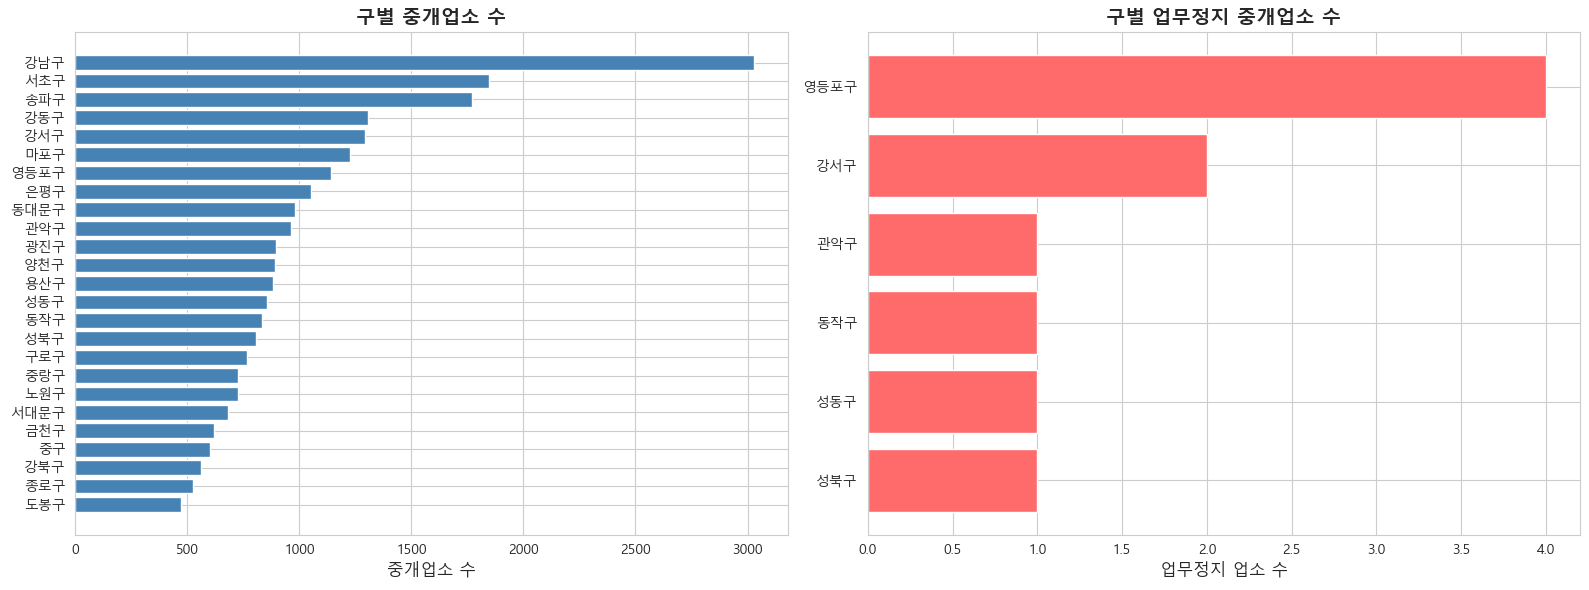


=== 중개업소 영업 상태 통계 ===
총 중개업소: 25,450개
영업중: 25,350개 (99.61%)
휴업: 86개
업무정지: 10개
휴업연장: 4개

=== 업무정지 업소가 있는 구 ===
region
영등포구    4
강서구     2
관악구     1
동작구     1
성동구     1
성북구     1
dtype: int64


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 구 이름 추출
broker_df['region'] = broker_df['addr'].str.extract(r'서울특별시\s*(\S+구)')

# 그래프
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. 구별 중개업소 수
broker_by_region = broker_df.groupby('region').size().reset_index(name='total_count')
broker_sorted = broker_by_region.sort_values('total_count', ascending=False)
axes[0].barh(broker_sorted['region'], broker_sorted['total_count'], color='steelblue')
axes[0].set_xlabel('중개업소 수', fontsize=12)
axes[0].set_title('구별 중개업소 수', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()

# 2. 구별 업무정지 업소 수
suspension_by_region = broker_df[broker_df['stts_se'] == '업무정지'].groupby('region').size().sort_values(ascending=False)
if len(suspension_by_region) > 0:
    axes[1].barh(suspension_by_region.index, suspension_by_region.values, color='#ff6b6b')
    axes[1].set_xlabel('업무정지 업소 수', fontsize=12)
    axes[1].set_title('구별 업무정지 중개업소 수', fontsize=14, fontweight='bold')
    axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# 통계 요약
print("\n=== 중개업소 영업 상태 통계 ===")
print(f"총 중개업소: {len(broker_df):,}개")
print(f"영업중: {(broker_df['stts_se']=='영업중').sum():,}개 ({(broker_df['stts_se']=='영업중').sum()/len(broker_df)*100:.2f}%)")
print(f"휴업: {(broker_df['stts_se']=='휴업').sum()}개")
print(f"업무정지: {(broker_df['stts_se']=='업무정지').sum()}개")
print(f"휴업연장: {(broker_df['stts_se']=='휴업연장').sum()}개")

print("\n=== 업무정지 업소가 있는 구 ===")
if len(suspension_by_region) > 0:
    print(suspension_by_region)

# 행정처분

In [6]:
# 2. 행정처분 CSV 읽기
try:
    penalty_df = pd.read_csv('../data/regionTemp/saleLand/행정처분.csv', encoding='utf-8')
except UnicodeDecodeError:
    try:
        penalty_df = pd.read_csv('../data/regionTemp/행정처분.csv', encoding='cp949')
    except UnicodeDecodeError:
        penalty_df = pd.read_csv('../data/regionTemp/행정처분.csv', encoding='euc-kr')

print("\n=== 행정처분 정보 ===")
print(f"데이터 shape: {penalty_df.shape}")
print(penalty_df.head())


=== 행정처분 정보 ===
데이터 shape: (3355, 10)
     년도  분기    시도명 시군구명  단속업소수  적발건수  고발센터신고건수  계  등록취소  업무정지
0  2017   1  서울특별시   중구      4     4         0  4     1     2
1  2017   1  서울특별시  성동구      0     1         1  1     0     1
2  2017   1  서울특별시  광진구      0     3         0  3     1     0
3  2017   1  서울특별시  중랑구      0     1         0  1     0     0
4  2017   1  서울특별시  강북구      0     2         0  2     1     1


> 서울시 부동산 중개업소 행정처분 현황 분석  
    - 연도별 행정처분(등록취소, 업무정지, 적발건수) 추이 분석  
    - 처분 유형별 비율 및 행정처분 건수 비교 시각화
    - 서울시 전체 및 구별 행정처분 통계 요약

전체 데이터: 3355건
서울특별시 데이터: 599건


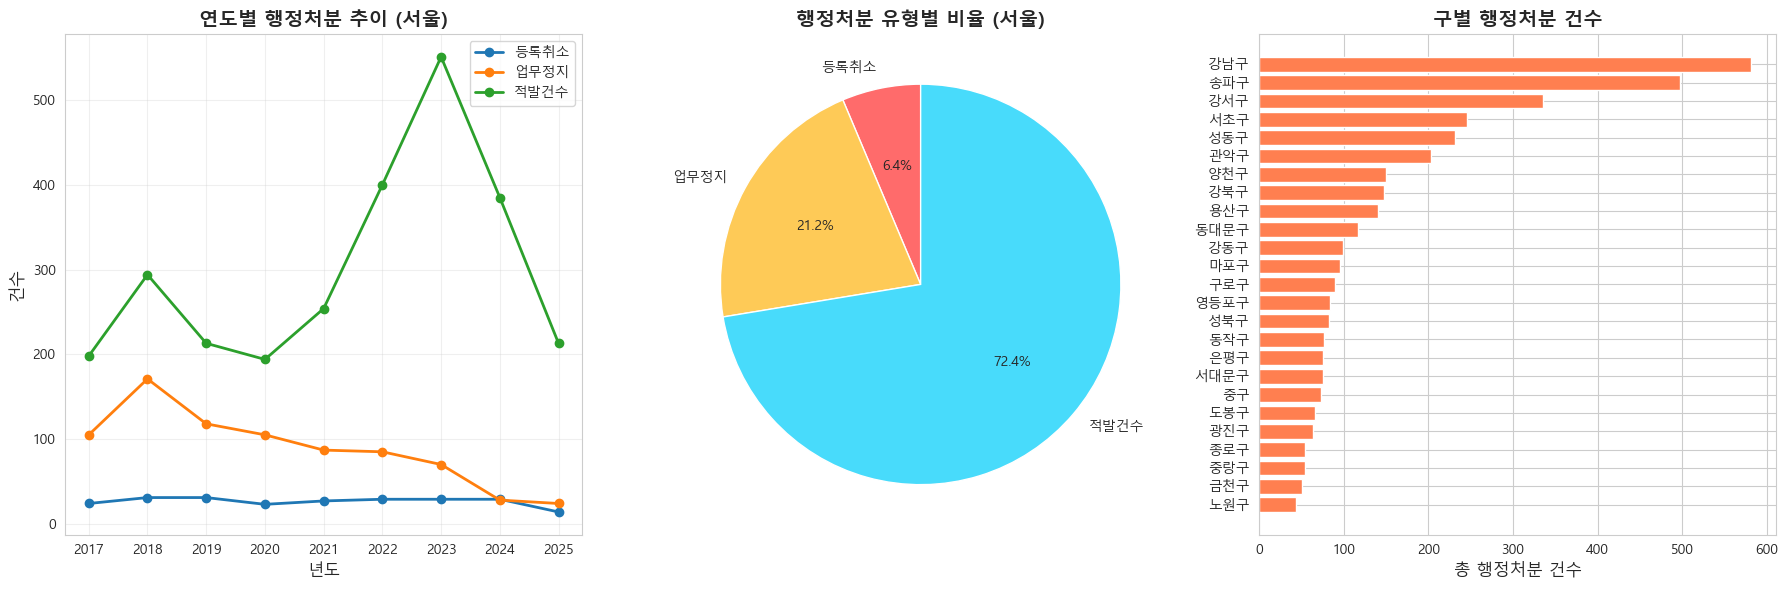


=== 서울시 행정처분 통계 ===
총 등록취소: 237건
총 업무정지: 793건
총 적발건수: 2702건
총 단속업소수: 543개

연도별 통계:
      등록취소  업무정지  적발건수
년도                    
2017    24   105   198
2018    31   171   294
2019    31   118   213
2020    23   105   194
2021    27    87   254
2022    29    85   400
2023    29    70   551
2024    29    28   385
2025    14    24   213

구별 행정처분 TOP 10:
      등록취소  업무정지  적발건수  총처분
시군구명                       
강남구     29   197   356  582
송파구     14    71   412  497
강서구     10    43   282  335
서초구      7    72   167  246
성동구      5    71   156  232
관악구      8    61   134  203
양천구     15    15   120  150
강북구     12    23   112  147
용산구     12    20   109  141
동대문구    18    23    76  117


In [21]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 서울특별시만 필터링
seoul_penalty = penalty_df[penalty_df['시도명'] == '서울특별시'].copy()

print(f"전체 데이터: {len(penalty_df)}건")
print(f"서울특별시 데이터: {len(seoul_penalty)}건")

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. 연도별 행정처분 추이
yearly_penalty = seoul_penalty.groupby('년도')[['등록취소', '업무정지', '적발건수']].sum()
yearly_penalty.plot(ax=axes[0], marker='o', linewidth=2)
axes[0].set_xlabel('년도', fontsize=12)
axes[0].set_ylabel('건수', fontsize=12)
axes[0].set_title('연도별 행정처분 추이 (서울)', fontsize=14, fontweight='bold')
axes[0].legend(['등록취소', '업무정지', '적발건수'])
axes[0].grid(True, alpha=0.3)

# 2. 처분 유형별 비율
penalty_types = seoul_penalty[['등록취소', '업무정지', '적발건수']].sum()
colors = ['#ff6b6b', '#feca57', '#48dbfb']
axes[1].pie(penalty_types, labels=['등록취소', '업무정지', '적발건수'], 
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('행정처분 유형별 비율 (서울)', fontsize=14, fontweight='bold')

# 3. 구별 행정처분 건수
penalty_by_region = seoul_penalty.groupby('시군구명')[['등록취소', '업무정지', '적발건수']].sum()
penalty_by_region['총처분'] = penalty_by_region.sum(axis=1)
penalty_sorted = penalty_by_region.sort_values('총처분', ascending=False)

axes[2].barh(penalty_sorted.index, penalty_sorted['총처분'], color='coral')
axes[2].set_xlabel('총 행정처분 건수', fontsize=12)
axes[2].set_title('구별 행정처분 건수', fontsize=14, fontweight='bold')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

# 통계 요약
print("\n=== 서울시 행정처분 통계 ===")
print(f"총 등록취소: {seoul_penalty['등록취소'].sum()}건")
print(f"총 업무정지: {seoul_penalty['업무정지'].sum()}건")
print(f"총 적발건수: {seoul_penalty['적발건수'].sum()}건")
print(f"총 단속업소수: {seoul_penalty['단속업소수'].sum()}개")

print(f"\n연도별 통계:")
print(yearly_penalty)

print(f"\n구별 행정처분 TOP 10:")
print(penalty_sorted[['등록취소', '업무정지', '적발건수', '총처분']].head(10))


# 경매 분석

In [ ]:
# 모든 구의 매각통계 파일 읽기
sale_files = glob.glob('../data/regionTemp/saleLand/지역별 매각통계_*.xls')

sale_dfs = []
for file_path in sale_files:
    region_name = os.path.basename(file_path).replace('지역별 매각통계_', '').replace('.xls', '')
    
    df = pd.read_excel(file_path, engine='xlrd')
    df['region'] = region_name
    sale_dfs.append(df)

sale_df = pd.concat(sale_dfs, ignore_index=True)

# 경매건수를 숫자로 변환
sale_df['경매건수'] = pd.to_numeric(sale_df['경매건수'], errors='coerce')

print("\n=== 지역별 매각통계 (전체 구) ===")
print(f"총 {len(sale_files)}개 구 데이터 로드 완료")
print(f"전체 데이터 shape: {sale_df.shape}")

# 구별 경매건수 확인
print("\n구별 경매건수:")
region_auction = sale_df.groupby('region')['경매건수'].sum().sort_values(ascending=False)
for region, count in region_auction.items():
    print(f"  {region}: {int(count)}건")



=== 지역별 매각통계 (전체 구) ===
총 25개 구 데이터 로드 완료
전체 데이터 shape: (353, 8)

구별 경매건수:
  구로구: 1960건
  성북구: 1800건
  관악구: 1754건
  동작구: 1754건
  중랑구: 1694건
  강북구: 1636건
  금천구: 1550건
  도봉구: 1538건
  송파구: 1502건
  은평구: 1345건
  서초구: 1338건
  서대문구: 1324건
  중구: 1252건
  강남구: 1250건
  강서구: 1173건
  강동구: 1166건
  영등포구: 1114건
  마포구: 998건
  노원구: 994건
  동대문구: 980건
  광진구: 866건
  양천구: 752건
  종로구: 718건
  성동구: 520건
  용산구: 372건


In [15]:
import pandas as pd
import glob
import os

# 파일 하나만 먼저 확인
sale_files = glob.glob('../data/regionTemp/saleLand/지역별 매각통계_*.xls')

if len(sale_files) > 0:
    # 첫 번째 파일 읽기
    sample_file = sale_files[0]
    print(f"샘플 파일: {os.path.basename(sample_file)}")
    
    sample_df = pd.read_excel(sample_file, engine='xlrd')
    
    print(f"\n데이터 shape: {sample_df.shape}")
    print(f"\n컬럼 목록:")
    print(sample_df.columns.tolist())
    
    print(f"\n데이터 샘플:")
    print(sample_df.head(10))
    
    print(f"\n데이터 타입:")
    print(sample_df.dtypes)
    
    print(f"\n기술 통계:")
    print(sample_df.describe())
else:
    print("파일을 찾을 수 없습니다.")


샘플 파일: 지역별 매각통계_강남구.xls

데이터 shape: (15, 7)

컬럼 목록:
['읍/면/동', '경매건수', '매각건수', '감정가(단위:원)', '매각가(단위:원)', '매각율', '매각가율']

데이터 샘플:
  읍/면/동  경매건수  매각건수       감정가(단위:원)       매각가(단위:원)    매각율    매각가율
0   개포동    19    12  24,191,180,000  23,750,370,714  63.2%   98.2%
1   논현동    57    18  19,127,329,910  16,312,252,344  31.6%   85.3%
2   대치동    88    25  77,748,686,860  66,122,865,350  28.4%     85%
3   도곡동    30    14  42,119,465,500  38,646,621,457  46.7%   91.8%
4   삼성동    56    18  51,583,638,720  46,003,313,488  32.1%   89.2%
5   세곡동    34    10   5,873,117,200   5,071,110,100  29.4%   86.3%
6   수서동    27    12  11,886,767,109   9,902,856,111  44.4%   83.3%
7   신사동     7     3   2,289,000,000   2,172,039,000  42.9%   94.9%
8  압구정동     5     4  13,836,000,000  14,849,099,998    80%  107.3%
9   역삼동   131    35  34,853,951,200  30,921,780,803  26.7%   88.7%

데이터 타입:
읍/면/동        object
경매건수          int64
매각건수          int64
감정가(단위:원)    object
매각가(단위:원)    object
매각율          object
매각가율  

> 서울시 구별 부동산 경매 현황 및 상관관계 분석  
    - 구별 경매건수 분포 및 TOP10 시각화  
    - 경매건수와 중개업소 수, 행정처분 간의 상관관계 분석  

경매 데이터가 있는 구: 25개
   region    경매건수
6     구로구  1960.0
16    성북구  1800.0
4     관악구  1754.0
11    동작구  1754.0
24    중랑구  1694.0
2     강북구  1636.0
7     금천구  1550.0
9     도봉구  1538.0
17    송파구  1502.0
21    은평구  1345.0
14    서초구  1338.0
13   서대문구  1324.0
23     중구  1252.0
0     강남구  1250.0
3     강서구  1173.0
1     강동구  1166.0
19   영등포구  1114.0
12    마포구   998.0
8     노원구   994.0
10   동대문구   980.0
5     광진구   866.0
18    양천구   752.0
22    종로구   718.0
15    성동구   520.0
20    용산구   372.0


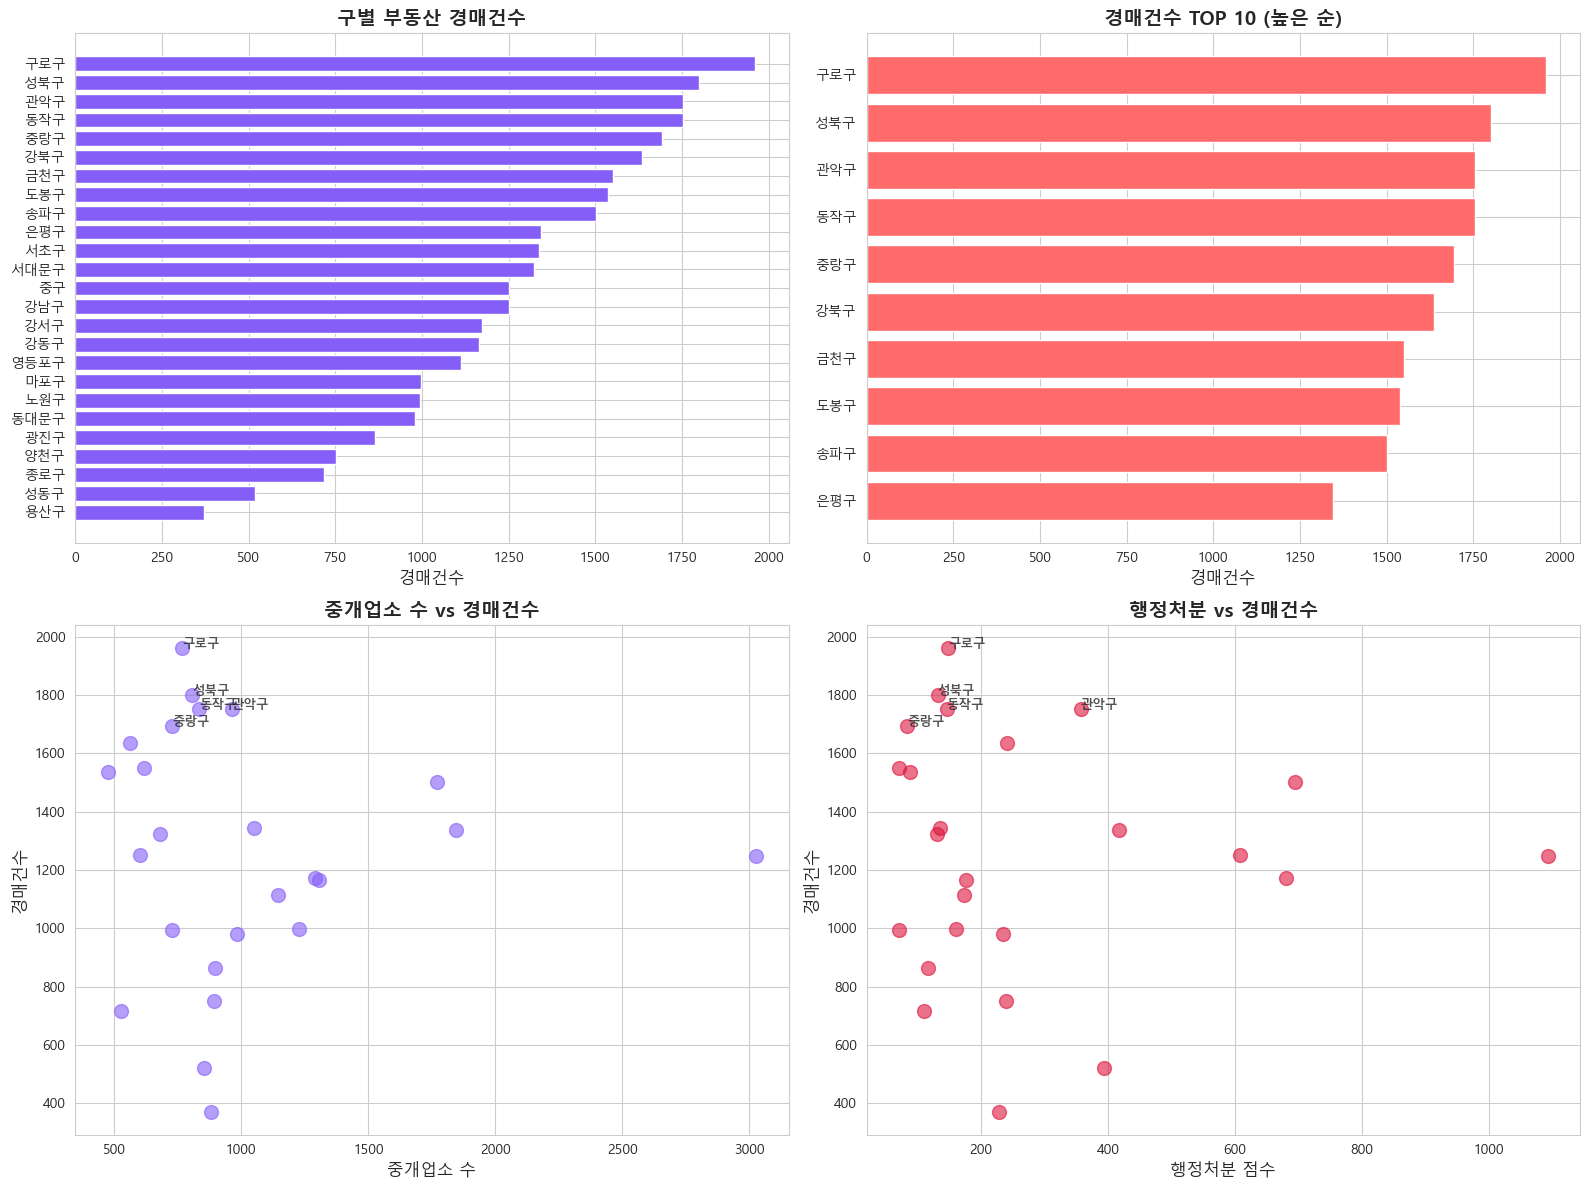


=== 경매 통계 ===
총 경매건수: 31350건
평균 (구당): 1254건
최대: 1960건 (구로구)
최소: 372건 (용산구)

중개업소 수 vs 경매건수 상관계수: -0.032
행정처분 vs 경매건수 상관계수: -0.043


In [10]:
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 구별 경매건수 집계
auction_by_region = sale_df.groupby('region')['경매건수'].sum().reset_index()
auction_by_region = auction_by_region.sort_values('경매건수', ascending=False)

print(f"경매 데이터가 있는 구: {len(auction_by_region)}개")
print(auction_by_region)

# 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. 구별 경매건수
axes[0, 0].barh(auction_by_region['region'], auction_by_region['경매건수'], color='#845ef7')
axes[0, 0].set_xlabel('경매건수', fontsize=12)
axes[0, 0].set_title('구별 부동산 경매건수', fontsize=14, fontweight='bold')
axes[0, 0].invert_yaxis()

# 2. 경매건수 TOP 10 vs BOTTOM 10 비교
top10 = auction_by_region.head(10)
bottom10 = auction_by_region.tail(10).sort_values('경매건수', ascending=True)

x = range(len(top10))
axes[0, 1].barh(top10['region'], top10['경매건수'], color='#ff6b6b', label='TOP 10')
axes[0, 1].set_xlabel('경매건수', fontsize=12)
axes[0, 1].set_title('경매건수 TOP 10 (높은 순)', fontsize=14, fontweight='bold')
axes[0, 1].invert_yaxis()

# 3. 경매건수 vs 중개업소 수
merged_auction = auction_by_region.merge(broker_by_region, on='region', how='left')
axes[1, 0].scatter(merged_auction['total_count'], merged_auction['경매건수'], 
                   s=100, alpha=0.6, color='#845ef7')
axes[1, 0].set_xlabel('중개업소 수', fontsize=12)
axes[1, 0].set_ylabel('경매건수', fontsize=12)
axes[1, 0].set_title('중개업소 수 vs 경매건수', fontsize=14, fontweight='bold')

# 구 이름 표시 (TOP 5만)
top5_auction = merged_auction.nlargest(5, '경매건수')
for idx, row in top5_auction.iterrows():
    axes[1, 0].annotate(row['region'], (row['total_count'], row['경매건수']), 
                        fontsize=9, alpha=0.8, fontweight='bold')

# 4. 경매건수 vs 행정처분
penalty_grouped = penalty_df.groupby('시군구명')['penalty_score'].sum().reset_index()
penalty_grouped.rename(columns={'시군구명': 'region'}, inplace=True)

merged_all = auction_by_region.merge(penalty_grouped, on='region', how='left')
axes[1, 1].scatter(merged_all['penalty_score'], merged_all['경매건수'], 
                   s=100, alpha=0.6, color='crimson')
axes[1, 1].set_xlabel('행정처분 점수', fontsize=12)
axes[1, 1].set_ylabel('경매건수', fontsize=12)
axes[1, 1].set_title('행정처분 vs 경매건수', fontsize=14, fontweight='bold')

# 구 이름 표시 (TOP 5만)
for idx, row in top5_auction.iterrows():
    matched = merged_all[merged_all['region'] == row['region']]
    if not matched.empty:
        axes[1, 1].annotate(row['region'], 
                           (matched.iloc[0]['penalty_score'], matched.iloc[0]['경매건수']), 
                           fontsize=9, alpha=0.8, fontweight='bold')

plt.tight_layout()
plt.show()

# 통계 요약
print("\n=== 경매 통계 ===")
print(f"총 경매건수: {auction_by_region['경매건수'].sum():.0f}건")
print(f"평균 (구당): {auction_by_region['경매건수'].mean():.0f}건")
print(f"최대: {auction_by_region['경매건수'].max():.0f}건 ({auction_by_region.loc[auction_by_region['경매건수'].idxmax(), 'region']})")
print(f"최소: {auction_by_region['경매건수'].min():.0f}건 ({auction_by_region.loc[auction_by_region['경매건수'].idxmin(), 'region']})")

# 상관계수
corr_broker = merged_auction['total_count'].corr(merged_auction['경매건수'])
print(f"\n중개업소 수 vs 경매건수 상관계수: {corr_broker:.3f}")

corr_penalty = merged_all['penalty_score'].corr(merged_all['경매건수'])
print(f"행정처분 vs 경매건수 상관계수: {corr_penalty:.3f}")


> 서울시 구별 부동산 경매 및 매각 현황 분석  
    - 전체 구의 경매건수, 매각건수, 매각율 데이터 통합 및 집계  
    - 구별 경매 활성도와 시장 수요(매각율) 비교분석  
    - 경매건수 TOP10 지역의 매각 성과 시각화 및 통계요약


=== 지역별 매각통계 (전체 구) ===
총 25개 구 데이터 로드 완료
전체 데이터 shape: (353, 8)

=== 구별 경매 분석 ===
   region    경매건수   매각건수     감정가(단위:원)     매각가(단위:원)         매각율
6     구로구  1960.0  892.0  318510074460  252807300646   45.510204
16    성북구  1800.0  458.0  261354612110  213496310064   25.444444
4     관악구  1754.0  778.0  474285896900  362075546526   44.355758
11    동작구  1754.0  484.0  315590893806  257224787092   27.594071
24    중랑구  1694.0  334.0  136708813702  107360795470   19.716647
2     강북구  1636.0  380.0  209724485740  168343955326   23.227384
7     금천구  1550.0  784.0  260832678080  198837820392   50.580645
9     도봉구  1538.0  382.0  166406320986  130023233380   24.837451
17    송파구  1502.0  370.0  433861420080  395862900606   24.633822
21    은평구  1345.0  610.0  250269820720  196334692536   45.353160
14    서초구  1338.0  318.0  618859384220  589308230218   23.766816
13   서대문구  1324.0  318.0  161444888040  134155658136   24.018127
23     중구  1252.0  232.0  150456098640  113355496620   18.530351
0     

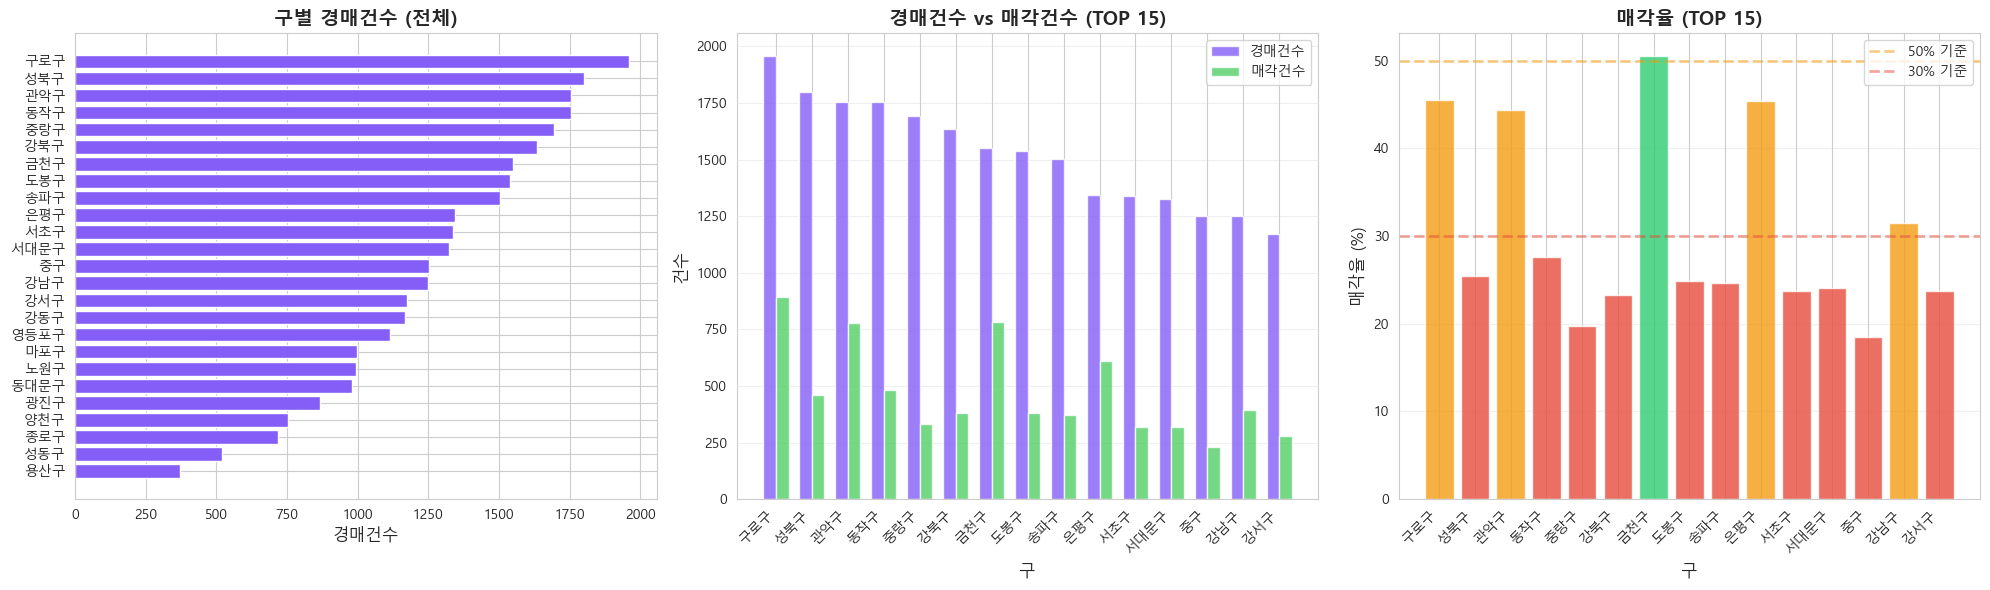


=== 경매 통계 요약 ===
총 경매건수: 31350건
총 매각건수: 10193건
총 감정가: 7,440,490,069,724원
총 매각가: 6,168,125,645,362원
전체 평균 매각율: 33.7%

=== 매각율 TOP 5 (수요 많음) ===
   region    경매건수   매각건수         매각율
18    양천구   752.0  948.0  126.063830
7     금천구  1550.0  784.0   50.580645
6     구로구  1960.0  892.0   45.510204
21    은평구  1345.0  610.0   45.353160
4     관악구  1754.0  778.0   44.355758

=== 매각율 BOTTOM 5 (시장 침체) ===
   region    경매건수   매각건수        매각율
23     중구  1252.0  232.0  18.530351
24    중랑구  1694.0  334.0  19.716647
2     강북구  1636.0  380.0  23.227384
14    서초구  1338.0  318.0  23.766816
3     강서구  1173.0  279.0  23.785166

=== 경매건수 TOP 15 ===
   region    경매건수   매각건수        매각율
6     구로구  1960.0  892.0  45.510204
16    성북구  1800.0  458.0  25.444444
4     관악구  1754.0  778.0  44.355758
11    동작구  1754.0  484.0  27.594071
24    중랑구  1694.0  334.0  19.716647
2     강북구  1636.0  380.0  23.227384
7     금천구  1550.0  784.0  50.580645
9     도봉구  1538.0  382.0  24.837451
17    송파구  1502.0  370.0  24.633822
21    은

In [25]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 한글 폰트 및 마이너스 기호 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 모든 구의 매각통계 파일 읽기
sale_files = glob.glob('../data/regionTemp/saleLand/지역별 매각통계_*.xls')
sale_dfs = []

for file_path in sale_files:
    region_name = os.path.basename(file_path).replace('지역별 매각통계_', '').replace('.xls', '')
    df = pd.read_excel(file_path, engine='xlrd')
    df['region'] = region_name
    sale_dfs.append(df)

sale_df = pd.concat(sale_dfs, ignore_index=True)

# 숫자로 변환
sale_df['경매건수'] = pd.to_numeric(sale_df['경매건수'], errors='coerce')
sale_df['매각건수'] = pd.to_numeric(sale_df['매각건수'], errors='coerce')
sale_df['감정가(단위:원)'] = pd.to_numeric(
    sale_df['감정가(단위:원)'].astype(str).str.replace(',', ''), 
    errors='coerce'
).fillna(0)
sale_df['매각가(단위:원)'] = pd.to_numeric(
    sale_df['매각가(단위:원)'].astype(str).str.replace(',', ''), 
    errors='coerce'
).fillna(0)

print("\n=== 지역별 매각통계 (전체 구) ===")
print(f"총 {len(sale_files)}개 구 데이터 로드 완료")
print(f"전체 데이터 shape: {sale_df.shape}")

# 구별 경매 데이터 집계
auction_analysis = sale_df.groupby('region').agg({
    '경매건수': 'sum',
    '매각건수': 'sum',
    '감정가(단위:원)': 'sum',
    '매각가(단위:원)': 'sum'
}).reset_index()

# 매각율 계산
auction_analysis['매각율'] = (auction_analysis['매각건수'] / auction_analysis['경매건수'] * 100).fillna(0)
auction_analysis['매각율'] = auction_analysis['매각율'].replace([np.inf, -np.inf], 0)

print("\n=== 구별 경매 분석 ===")
print(auction_analysis.sort_values('경매건수', ascending=False))

# 시각화 (1행 3열로 변경)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. 구별 경매건수 (전체)
auction_sorted = auction_analysis.sort_values('경매건수', ascending=False)
axes[0].barh(auction_sorted['region'], auction_sorted['경매건수'], color='#845ef7')
axes[0].set_xlabel('경매건수', fontsize=12)
axes[0].set_title('구별 경매건수 (전체)', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()

# 2. 경매건수 vs 매각건수 (TOP 15)
top15_auction = auction_analysis.nlargest(15, '경매건수').reset_index(drop=True)
x = np.arange(len(top15_auction))
width = 0.35

axes[1].bar(x - width/2, top15_auction['경매건수'], width, 
            label='경매건수', color='#845ef7', alpha=0.8)
axes[1].bar(x + width/2, top15_auction['매각건수'], width, 
            label='매각건수', color='#51cf66', alpha=0.8)
axes[1].set_xlabel('구', fontsize=12)
axes[1].set_ylabel('건수', fontsize=12)
axes[1].set_title('경매건수 vs 매각건수 (TOP 15)', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(top15_auction['region'], rotation=45, ha='right')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# 3. 매각율 (TOP 15)
# 매각율 기준으로 색상 구분
colors_rate = ['#2ecc71' if x >= 50 else '#f39c12' if x >= 30 else '#e74c3c' 
               for x in top15_auction['매각율']]

axes[2].bar(x, top15_auction['매각율'], color=colors_rate, alpha=0.8)
axes[2].axhline(50, color='#f39c12', linestyle='--', alpha=0.5, linewidth=2, label='50% 기준')
axes[2].axhline(30, color='#e74c3c', linestyle='--', alpha=0.5, linewidth=2, label='30% 기준')
axes[2].set_xlabel('구', fontsize=12)
axes[2].set_ylabel('매각율 (%)', fontsize=12)
axes[2].set_title('매각율 (TOP 15)', fontsize=14, fontweight='bold')
axes[2].set_xticks(x)
axes[2].set_xticklabels(top15_auction['region'], rotation=45, ha='right')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 통계 요약
print("\n=== 경매 통계 요약 ===")
print(f"총 경매건수: {auction_analysis['경매건수'].sum():.0f}건")
print(f"총 매각건수: {auction_analysis['매각건수'].sum():.0f}건")
print(f"총 감정가: {auction_analysis['감정가(단위:원)'].sum():,.0f}원")
print(f"총 매각가: {auction_analysis['매각가(단위:원)'].sum():,.0f}원")
print(f"전체 평균 매각율: {auction_analysis['매각율'].mean():.1f}%")

print("\n=== 매각율 TOP 5 (수요 많음) ===")
print(auction_analysis.nlargest(5, '매각율')[['region', '경매건수', '매각건수', '매각율']])

print("\n=== 매각율 BOTTOM 5 (시장 침체) ===")
print(auction_analysis.nsmallest(5, '매각율')[['region', '경매건수', '매각건수', '매각율']])

print("\n=== 경매건수 TOP 15 ===")
print(auction_analysis.nlargest(15, '경매건수')[['region', '경매건수', '매각건수', '매각율']])


# 허위매물 온도 지표